# **Tugas Praktikum Mandiri 11 - DBSCAN**

# Instalasi Library

In [70]:
!pip install folium

In [71]:
!pip install contextily

# Import Library

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap
import geopandas as gpd
import contextily as ctx
from shapely import wkt

# Load Dataset

In [73]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Machine Learning/Praktikum11/Data/AB_NYC_2019.csv')
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


# Informasi Dataset

In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

# Cleaning Data

In [75]:
df.isnull().sum()

,0
id,0
name,16
host_id,0
host_name,21
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


In [76]:
df.duplicated().sum()

np.int64(0)

In [77]:
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)

In [78]:
# drop fitur lain yang kosong
df.dropna(inplace=True)

In [79]:
df.isnull().sum()

,0
id,0
name,0
host_id,0
host_name,0
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


# Visualisasi Heatmap Sebaran NYC Airbnb (Latitude–Longitude)

In [80]:
coords = df[['latitude', 'longitude']].dropna().values.tolist()

In [81]:
m = folium.Map(
    location=[df['latitude'].mean(), df['longitude'].mean()],
    zoom_start=11
)

HeatMap(coords, radius=8).add_to(m)
m

# Dengan Jittering (Supaya tidak menumpuk)

In [82]:
df['lat_j'] = df['latitude'] + np.random.normal(0, 0.0005, len(df))
df['lon_j'] = df['longitude'] + np.random.normal(0, 0.0005, len(df))

coords_jitter = df[['lat_j', 'lon_j']].values.tolist()

m2 = folium.Map(location=[df['lat_j'].mean(), df['lon_j'].mean()], zoom_start=11)
HeatMap(coords_jitter, radius=8).add_to(m2)
m2

# Visualisasi Basemap NYC

In [83]:
gdf = gpd.GeoDataFrame(
    df.dropna(subset=['latitude', 'longitude']),
    geometry=gpd.points_from_xy(df['longitude'], df['latitude']),
    crs='EPSG:4326'
)

gdf = gdf.to_crs(epsg=3857)

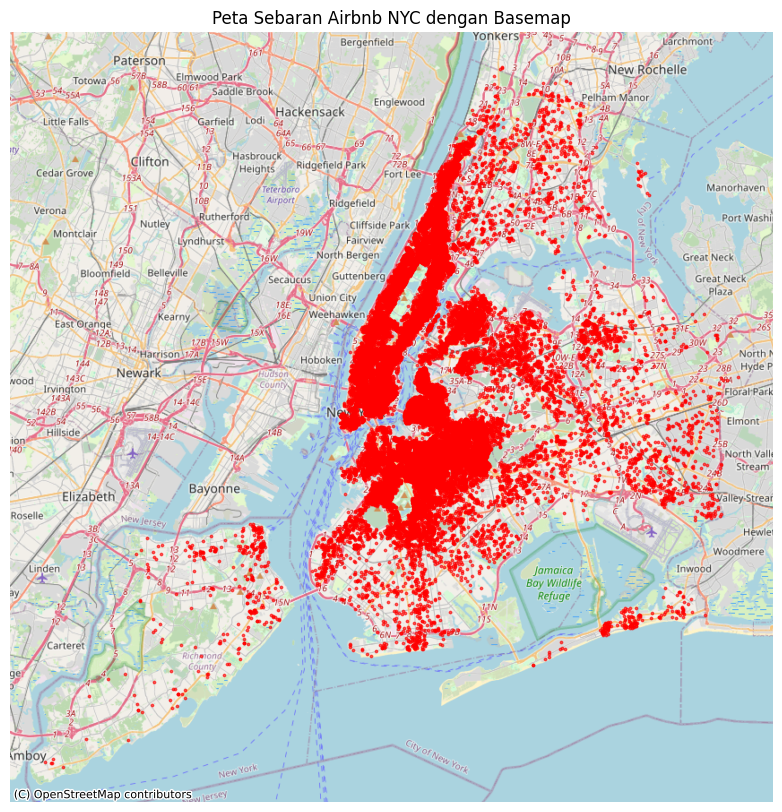

In [84]:
fig, ax = plt.subplots(figsize=(10, 10))
gdf.plot(ax=ax, alpha=0.6, markersize=3, color='red')

ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)
ax.set_axis_off()
plt.title("Peta Sebaran Airbnb NYC dengan Basemap")
plt.show()

# Visualisasi Peta + Grafik Harga Tertinggi & Terendah

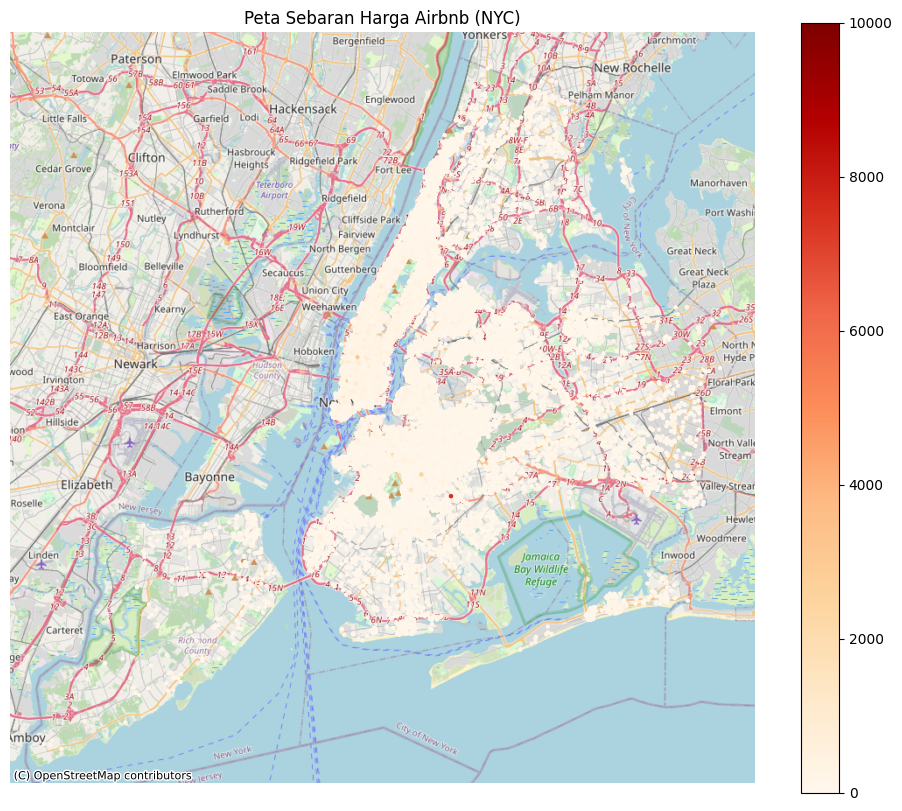

In [85]:
fig, ax = plt.subplots(figsize=(12, 10))

gdf.plot(
    ax=ax,
    column='price',
    cmap='OrRd',
    markersize=5,
    legend=True
)

ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)
ax.set_title("Peta Sebaran Harga Airbnb (NYC)")
ax.set_axis_off()
plt.show()

/tmp/ipython-input-4231906093.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top5, x='price', y='name', palette='RdPu')


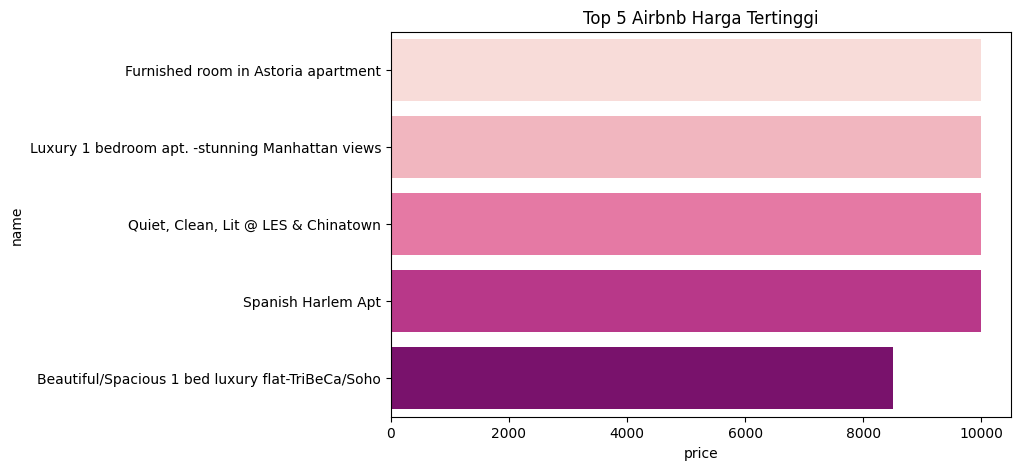

In [86]:
# TOP 5 HIGHEST PRICE
top5 = df[['name','neighbourhood_group','price']].sort_values('price', ascending=False).head(5)
plt.figure(figsize=(8,5))
sns.barplot(data=top5, x='price', y='name', palette='RdPu')
plt.title("Top 5 Airbnb Harga Tertinggi")
plt.show()

/tmp/ipython-input-3770204390.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bottom5, x='price', y='name', palette='Blues')


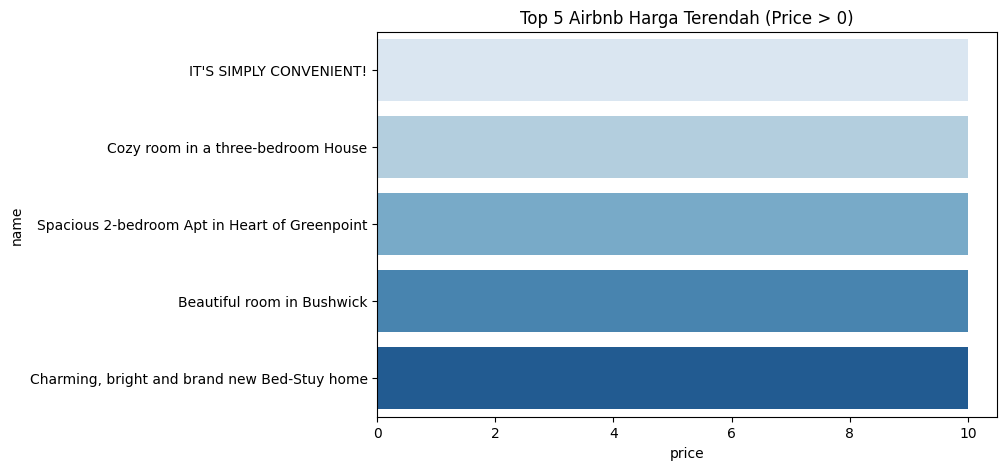

In [87]:
# TOP 5 LOWEST PRICE
bottom5 = df[df['price'] > 0][['name','neighbourhood_group','price']] \
            .sort_values('price', ascending=True).head(5)
plt.figure(figsize=(8,5))
sns.barplot(data=bottom5, x='price', y='name', palette='Blues')
plt.title("Top 5 Airbnb Harga Terendah (Price > 0)")
plt.show()

# Uji Normalitas (Shapiro)

In [88]:
from scipy.stats import shapiro

cols = ['price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'availability_365']
normality_df = df[cols]

stat, p = shapiro(normality_df['price'])
print("Statistik:", stat)
print("P-value:", p)

if p > 0.05:
    print("Data berdistribusi normal (H0 diterima)")
else:
    print("Data tidak berdistribusi normal (H0 ditolak)")

Statistik: 0.32336252101402607
P-value: 7.526189284179659e-144
Data tidak berdistribusi normal (H0 ditolak)


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 38821.
  res = hypotest_fun_out(*samples, **kwds)


# Korelasi Spearman

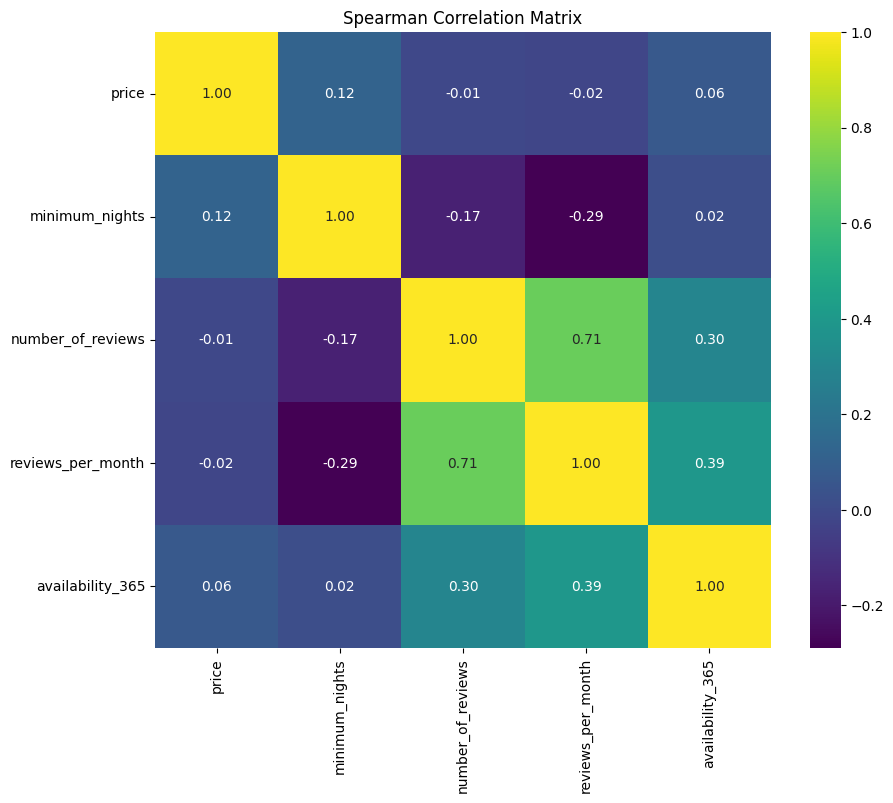

In [89]:
spearman_corr = normality_df.corr(method='spearman')

plt.figure(figsize=(10, 8))
sns.heatmap(spearman_corr, annot=True, cmap='viridis', fmt=".2f", square=True)
plt.title("Spearman Correlation Matrix")
plt.show()

# Normalisasi Data dengan RobustScaler

In [90]:
from sklearn.preprocessing import RobustScaler

cols_for_clustering = [
    'price',
    'minimum_nights',
    'number_of_reviews',
    'reviews_per_month',
    'availability_365'
]

X = df[cols_for_clustering]

scaler = RobustScaler()
X_scaled_array = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled_array, columns=cols_for_clustering, index=X.index)
X_scaled.head()

,price,minimum_nights,number_of_reviews,reviews_per_month,availability_365
0,0.475248,-0.333333,0.000000,-0.278689,1.353712
1,1.227723,-0.333333,1.200000,-0.185792,1.310044
3,-0.118812,-0.333333,8.700000,2.142077,0.606987
4,-0.207921,2.666667,0.000000,-0.338798,-0.240175
5,0.980198,0.333333,2.166667,-0.071038,0.323144


# Menentukan EPS dengan K-Distance Graph

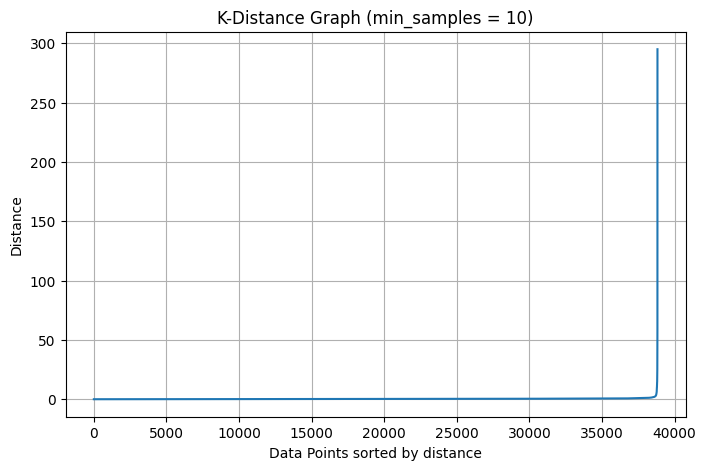

array([ 16.01484077,  16.03818177,  16.93787995,  20.06256032,
        20.08695121,  20.0924462 ,  20.27803068,  24.29861547,
        25.01717138,  29.74910172,  35.56927176,  45.00946312,
        45.01568528,  49.5053287 ,  49.51506189,  58.41466285,
        58.60977753, 211.33435979, 211.33534603, 295.00079088])

In [91]:
from sklearn.neighbors import NearestNeighbors

min_samples = 10
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

distances = np.sort(distances[:, -1])

plt.figure(figsize=(8,5))
plt.plot(distances)
plt.title("K-Distance Graph (min_samples = 10)")
plt.xlabel("Data Points sorted by distance")
plt.ylabel("Distance")
plt.grid(True)
plt.show()

distances[-20:]

# DBSCAN Clustering

In [92]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.30, min_samples=10)
labels = dbscan.fit_predict(X_scaled)

labels[:20]

array([ 0, -1, -1,  1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1,  2, -1])

In [93]:
df['cluster'] = pd.Series(labels, index=df.index)
df['cluster'].value_counts()

,count
cluster,
-1,12944
3,7222
0,6539
2,4474
8,1865
...,...
33,7
28,6
65,6


# Silhouette Score

In [100]:
from sklearn.metrics import silhouette_score

mask = df['cluster'] != -1
sil_score = silhouette_score(X_scaled[mask], df['cluster'][mask])
sil_score

np.float64(0.28586479117)

# Visualisasi Clustering PCA 2D

In [95]:
from sklearn.decomposition import PCA

dbscan = DBSCAN(eps=0.6, min_samples=10)
labels = dbscan.fit_predict(X_scaled)

df['cluster'] = labels

pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)

df['pca1'] = pca_result[:, 0]
df['pca2'] = pca_result[:, 1]

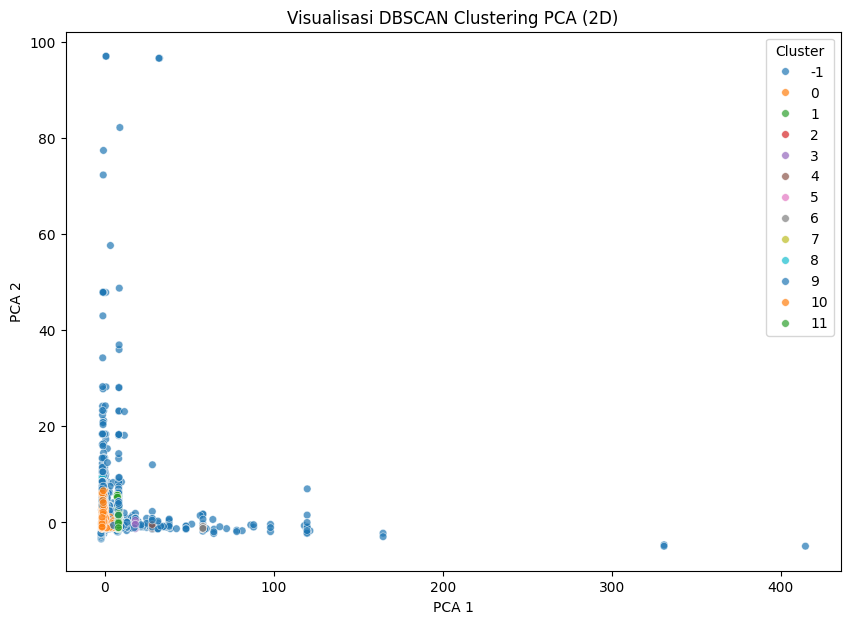

In [96]:
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df,
    x='pca1',
    y='pca2',
    hue='cluster',
    palette='tab10',
    s=30,
    alpha=0.7
)
plt.title("Visualisasi DBSCAN Clustering PCA (2D)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend(title='Cluster')
plt.show()

# Visualisasi Cluster pada Peta NYC

In [97]:
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df['longitude'], df['latitude']),
    crs='EPSG:4326'
)

In [98]:
gdf = gdf.to_crs(epsg=3857)

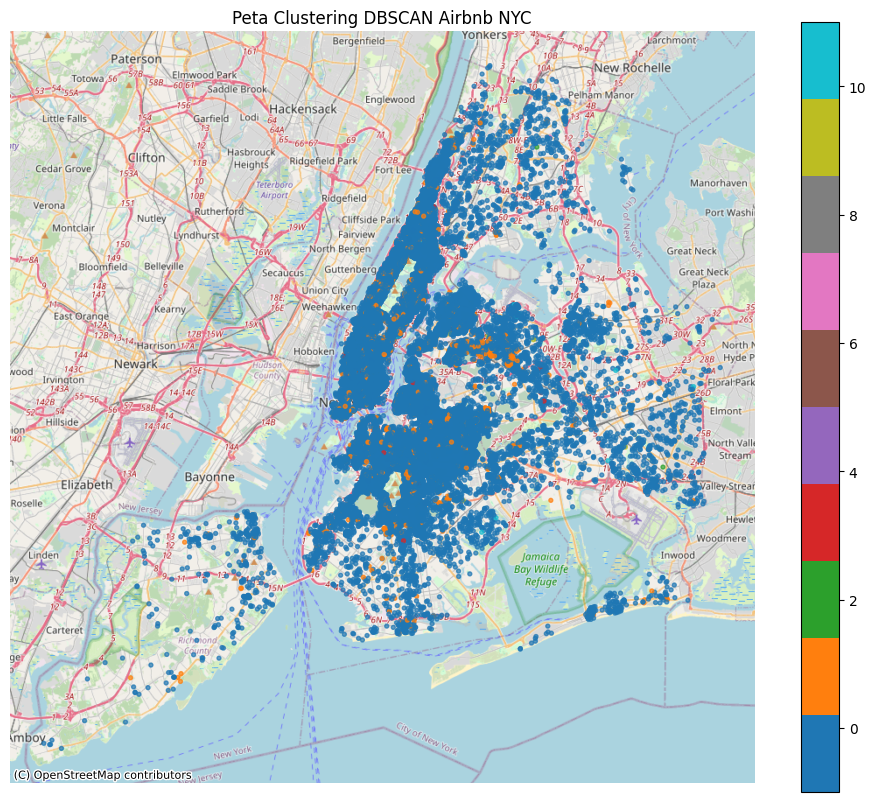

In [99]:
fig, ax = plt.subplots(figsize=(12, 10))

gdf.plot(
    ax=ax,
    column='cluster',
    cmap='tab10',
    markersize=8,
    legend=True,
    alpha=0.7
)

ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)
ax.set_title("Peta Clustering DBSCAN Airbnb NYC")
ax.set_axis_off()
plt.show()